In [4]:
from config import NAVY, RED, GREY, BG

# Credit Score (0-1000 Scale)

Converts the fitted Logistic Regression model into a 0–1000 credit score using log-odds scaling.

**Steps:**
1. Save artifacts from `04_modelling.ipynb`
2. Load them here
3. Define scaling parameters
4. Score every observation
5. Validate (AUC, Gini, KS, distribution)
6. Export scored data to CSV

> **Higher score = lower credit risk**

## Step 1 - Save Artifacts from `04_modelling.ipynb`

**Run this block at the bottom of `04_modelling.ipynb` before switching to this notebook:**

```python
import pickle

artifacts = {
    'lr_model'      : lr,             # fitted LogisticRegression
    'X_train_scaled': X_train_scaled, # scaled training features (ndarray)
    'X_test_scaled' : X_test_scaled,  # scaled test features (ndarray)
    'X_train'       : X_train,        # original (unscaled) train DataFrame
    'X_test'        : X_test,         # original (unscaled) test DataFrame
    'y_train'       : y_train,
    'y_test'        : y_test,
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved ✅")
```

Once that's done, come back here and run from Step 2 onwards.

## Step 2 - Imports

In [5]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


## Step 3 - Load Artifacts

In [6]:
with open('model_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

lr              = artifacts['lr_model']
X_train_scaled  = artifacts['X_train_scaled']
X_test_scaled   = artifacts['X_test_scaled']
X_train         = artifacts['X_train']
X_test          = artifacts['X_test']
y_train         = artifacts['y_train']
y_test          = artifacts['y_test']

print("Artifacts loaded ✅")
print(f"Train: {len(y_train):,} obs  |  Test: {len(y_test):,} obs")
print(f"Bad rate - Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")
print(f"LR coefficients: {lr.coef_.shape[1]} features")

KeyError: 'X_train_scaled'

## Step 4 - Scaling Parameters

The score is derived from the model's log-odds output, scaled onto a 0–1000 range.

```
log_odds  = log( P(bad) / P(good) )
Score     = Offset − Factor × log_odds
```

| Parameter | Value | Meaning |
|---|---|---|
| **PDO** | 50 | Points needed to double the odds |
| **Base Score** | 500 | Score assigned at 1:1 odds (50% bad rate) |
| **Base Odds** | 1 | Good:Bad odds at the base score |

In [ ]:
PDO        = 50    # Points to Double Odds
BASE_SCORE = 500   # Score at base odds
BASE_ODDS  = 1     # Good:Bad odds at the base score

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print(f"Factor : {factor:.4f}")
print(f"Offset : {offset:.4f}")
print()
print("Interpretation:")
print(f"  An applicant with 1:1 odds (50% default chance) scores {BASE_SCORE}")
print(f"  Every doubling of odds moves the score by {PDO} points")

Factor : 72.1348
Offset : 500.0000

Interpretation:
  An applicant with 1:1 odds (50% default chance) scores 500
  Every doubling of odds moves the score by 50 points


## Step 5 - Generate Scores

The model outputs `P(bad)` for each applicant. We convert that to log-odds, then apply the scaling formula. Scores are clipped to [0, 1000] and rounded to integers.

In [ ]:
def score_applicants(X_scaled, lr, factor, offset, clip=(0, 1000)):
    """
    Convert scaled features → credit score (integer, 0–1000).
    Higher score = lower risk.
    """
    p_bad     = lr.predict_proba(X_scaled)[:, 1]
    p_bad     = np.clip(p_bad, 1e-6, 1 - 1e-6)   # avoid log(0)
    log_odds  = np.log(p_bad / (1 - p_bad))
    scores    = offset - factor * log_odds
    scores    = np.clip(scores, clip[0], clip[1])
    return np.round(scores).astype(int)


train_scores = score_applicants(X_train_scaled, lr, factor, offset)
test_scores  = score_applicants(X_test_scaled,  lr, factor, offset)

print("Score Summary")
print("=" * 45)
print(f"{'Set':<8} {'Min':>5} {'Max':>5} {'Mean':>7} {'Median':>8} {'Std':>7}")
print("-" * 45)
for label, scores in [('Train', train_scores), ('Test', test_scores)]:
    print(f"{label:<8} {scores.min():>5} {scores.max():>5} "
          f"{scores.mean():>7.1f} {np.median(scores):>8.1f} {scores.std():>7.1f}")

Score Summary
Set        Min   Max    Mean   Median     Std
---------------------------------------------
Train      185   867   525.8    529.5   108.7
Test       257   774   522.0    519.0   108.0


## Step 6 - Validate

In [ ]:
# ── Metrics ────────────────────────────────────────────────────────────────────
auc  = roc_auc_score(y_test, -test_scores)   # negate: high score = low risk
gini = 2 * auc - 1

good_scores = test_scores[y_test.values == 0]
bad_scores  = test_scores[y_test.values == 1]
ks_stat, _  = ks_2samp(good_scores, bad_scores)

print("Scorecard Validation (Test Set)")
print("=" * 35)
print(f"AUC:  {auc:.4f}")
print(f"Gini: {gini:.4f}")
print(f"KS:   {ks_stat:.4f}")

Scorecard Validation (Test Set)
AUC:  0.8261
Gini: 0.6521
KS:   0.6000


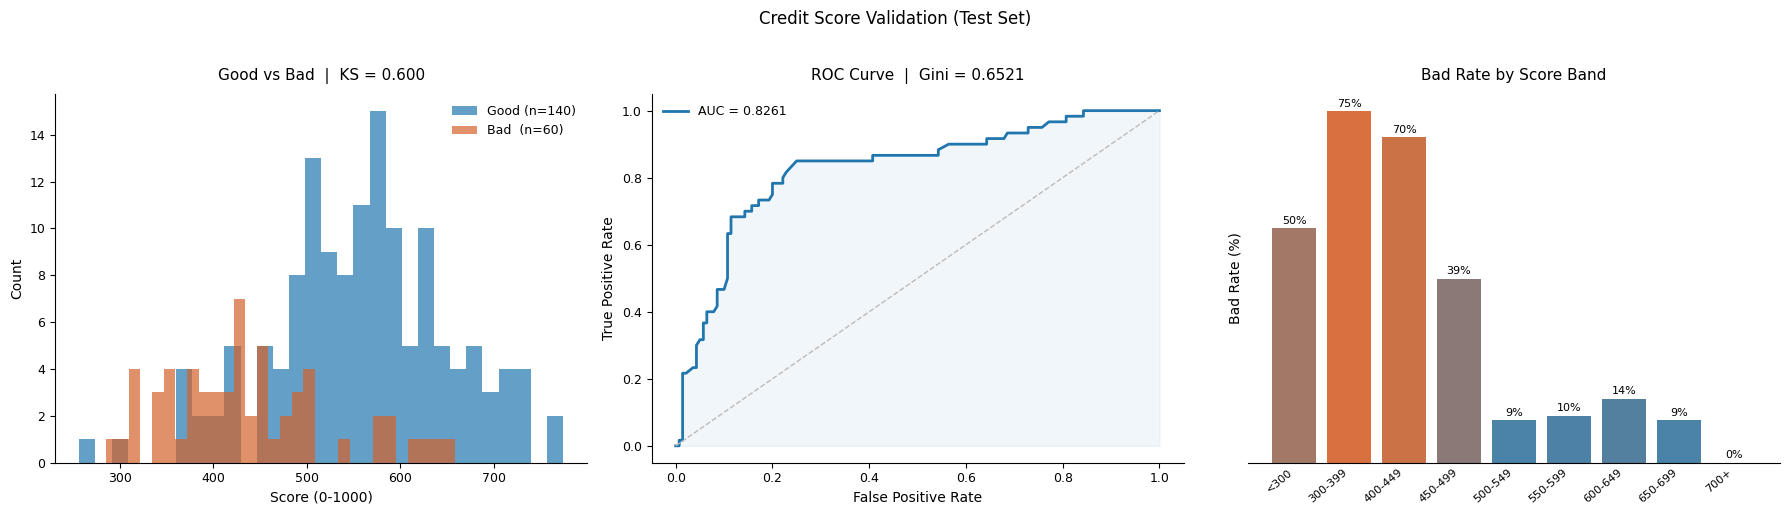

Plot saved: score_validation.png


In [ ]:
import matplotlib as mpl
mpl.rcParams.update({
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : True,
    'axes.spines.bottom': True,
    'axes.grid'         : False,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'font.family'       : 'sans-serif',
    'axes.titlesize'    : 11,
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'axes.titlepad'     : 10,
})
BLUE   = '#2176AE'
ORANGE = '#D4622A'

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Credit Score Validation (Test Set)', fontsize=12, y=1.02)

# 1 - Good vs Bad distribution
axes[0].hist(good_scores, bins=30, color=BLUE,   alpha=0.7,
             label=f'Good (n={len(good_scores):,})')
axes[0].hist(bad_scores,  bins=30, color=ORANGE, alpha=0.7,
             label=f'Bad  (n={len(bad_scores):,})')
axes[0].set_xlabel('Score (0-1000)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Good vs Bad  |  KS = {ks_stat:.3f}')
axes[0].legend(fontsize=9, frameon=False)

# 2 - ROC Curve
fpr, tpr, _ = roc_curve(y_test, -test_scores)
axes[1].plot(fpr, tpr, color=BLUE, lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='#BBBBBB', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.06, color=BLUE)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve  |  Gini = {gini:.4f}')
axes[1].legend(fontsize=9, frameon=False)

# 3 - Bad rate by score band with blue-to-orange gradient
bins   = [0, 300, 400, 450, 500, 550, 600, 650, 700, 1001]
labels = ['<300','300-399','400-449','450-499','500-549',
          '550-599','600-649','650-699','700+']

all_df = pd.DataFrame({'Score': test_scores, 'Bad': y_test.values})
all_df['Band'] = pd.cut(all_df['Score'], bins=bins, labels=labels, right=False)
band_bad = all_df.groupby('Band', observed=True)['Bad'].mean()

cmap   = mcolors.LinearSegmentedColormap.from_list('bo', [BLUE, ORANGE])
norm   = band_bad.values / max(band_bad.max(), 1e-6)
colors = [cmap(v) for v in norm]

axes[2].bar(range(len(band_bad)), band_bad.values * 100, color=colors, alpha=0.9)
axes[2].set_xticks(range(len(band_bad)))
axes[2].set_xticklabels(band_bad.index, rotation=40, ha='right', fontsize=8)
axes[2].set_ylabel('Bad Rate (%)')
axes[2].set_title('Bad Rate by Score Band')
axes[2].spines['left'].set_visible(False)
axes[2].set_yticks([])
for j, v in enumerate(band_bad.values):
    axes[2].text(j, v * 100 + 0.5, f'{v:.0%}', ha='center', va='bottom', fontsize=8)

axes[2].tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('score_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: score_validation.png")


### Score Band Table

In [ ]:
bins   = [0, 300, 400, 450, 500, 550, 600, 650, 700, 1001]
labels = ['<300','300–399','400–449','450–499','500–549',
          '550–599','600–649','650–699','700+']

band_df = pd.DataFrame({'Score': test_scores, 'Bad': y_test.values})
band_df['Band'] = pd.cut(band_df['Score'], bins=bins, labels=labels, right=False)

table = (
    band_df.groupby('Band', observed=True)
    .agg(Count=('Score','count'), Bads=('Bad','sum'))
    .assign(
        Goods    = lambda d: d['Count'] - d['Bads'],
        Bad_Rate = lambda d: (d['Bads']  / d['Count']).map('{:.1%}'.format),
        Pct_Pop  = lambda d: (d['Count'] / d['Count'].sum()).map('{:.1%}'.format),
    )
    .reset_index()
)

print("Score Band Analysis (Test Set)")
print("=" * 60)
print(table.to_string(index=False))

Score Band Analysis (Test Set)
   Band  Count  Bads  Goods Bad_Rate Pct_Pop
   <300      2     1      1    50.0%    1.0%
300–399     28    21      7    75.0%   14.0%
400–449     23    16      7    69.6%   11.5%
450–499     28    11     17    39.3%   14.0%
500–549     33     3     30     9.1%   16.5%
550–599     40     4     36    10.0%   20.0%
600–649     22     3     19    13.6%   11.0%
650–699     11     1     10     9.1%    5.5%
   700+     13     0     13     0.0%    6.5%


## Step 7 - Export Scored Data

In [ ]:
# Combine original features with scores
train_out = X_train.copy()
train_out['Score'] = train_scores
train_out['Bad']   = y_train.values
train_out['Split'] = 'train'

test_out  = X_test.copy()
test_out['Score'] = test_scores
test_out['Bad']   = y_test.values
test_out['Split'] = 'test'

scored = pd.concat([train_out, test_out], ignore_index=True)
scored.to_csv('scored_applicants.csv', index=False)

print(f"Exported → scored_applicants.csv")
print(f"Rows: {len(scored):,}  |  Columns: {len(scored.columns)}")
print()
print(scored[['Score','Bad','Split']].head(10).to_string(index=False))

Exported → scored_applicants.csv
Rows: 1,000  |  Columns: 21

 Score  Bad Split
   506    1 train
   637    0 train
   484    0 train
   320    0 train
   475    0 train
   673    0 train
   583    0 train
   579    0 train
   267    0 train
   356    1 train
